## The Hull-White One-Factor Model

The Hull-White one-factor model (HW1F) is a short rate model that extends the Vasicek model by allowing the drift to be time-dependent, enabling an exact fit to any initial term structure of interest rates. The dynamics under the risk-neutral measure $\mathbb{Q}$ are given by

$$dr_t = (\theta(t) - a r_t)dt + \sigma \, dW_t$$

where $a > 0$ is the mean-reversion speed, $\sigma > 0$ is the volatility of the short rate, and $W_t$ is a standard Brownian motion under $\mathbb{Q}$. The function $\theta(t)$ is chosen to perfectly fit the initial market term structure $\{f^M(0,t)\}_{t \geq 0}$, and is given by

$$\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a f^M(0,t) + \frac{\sigma^2}{2a}(1 - e^{-2at})$$

In this notebook, we implement the Hull-White model from scratch, without using QuantLib.

**Distributional properties.** Since the dynamics are linear and driven by a single Brownian motion, $r_t$ is Gaussian conditionally on $\mathcal{F}_s$ for any $s \leq t$. Its conditional mean and variance are

$$\mathbb{E}[r_t \mid \mathcal{F}_s] = e^{-a(t-s)}(r_s - \alpha(s)) + \alpha(t), \qquad \mathbb{V}[r_t \mid \mathcal{F}_s] = \frac{\sigma^2}{2a}\left(1 - e^{-2a(t-s)}\right)$$

where the deterministic function $\alpha(t)$ represents the mean-reversion level of the short rate

$$\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

Note that as $t \to \infty$, the variance converges to the stationary value $\frac{\sigma^2}{2a}$, confirming that mean-reversion prevents unbounded dispersion of rates.

**Implementation.** For simplicity, we discretize a 30-year horizon into 360 monthly intervals, without accounting for holidays etc.

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import HW1F
import stripping
YieldCurve = stripping.YieldCurve
importlib.reload(HW1F)
from scipy.optimize import minimize
from scipy.stats import norm
HullWhite1F = HW1F.HullWhite1F

In [101]:
yield_curve = pd.read_excel("Market Data/usdois.xlsx")
dates = yield_curve["dates"]
discount_factors = yield_curve["discounts"]
yield_curve_model = YieldCurve(dates,discount_factors,dates[0])
sigma = 0.1 #Volatility
a = 0.1 #Mean reverting speed level
model=HullWhite1F(a,sigma,yield_curve_model.forward_curve,yield_curve_model.time)


## Simulation of Short Rate Paths

We now simulate short rate paths using the calibrated Hull-White model with 
the USD OIS forward curve as of July 2016 as input. Paths are simulated over 
a 30-year horizon with monthly time steps ($\Delta t = 1/12$), using the exact 
conditional distribution of $r_t$ given $r_s$:

$$r_{t+\Delta t} \mid r_t \sim \mathcal{N}\left(e^{-a\Delta t}(r_t - \alpha(t)) + \alpha(t+\Delta t),\ \frac{\sigma^2}{2a}(1-e^{-2a\Delta t})\right)$$

The deterministic envelope $\alpha(t)$ represents the unconditional mean of 
$r_t$ given $\mathcal{F}_0$:

$$\mathbb{E}[r_t \mid \mathcal{F}_0] = \alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1-e^{-at})^2$$

and is plotted alongside the simulated paths as a reference. The low rate 
environment of 2016 is visible in the forward curve, with rates close to zero 
at the short end — a regime where the Gaussian nature of HW1F allows for 
negative rates, consistent with the market context at the time.

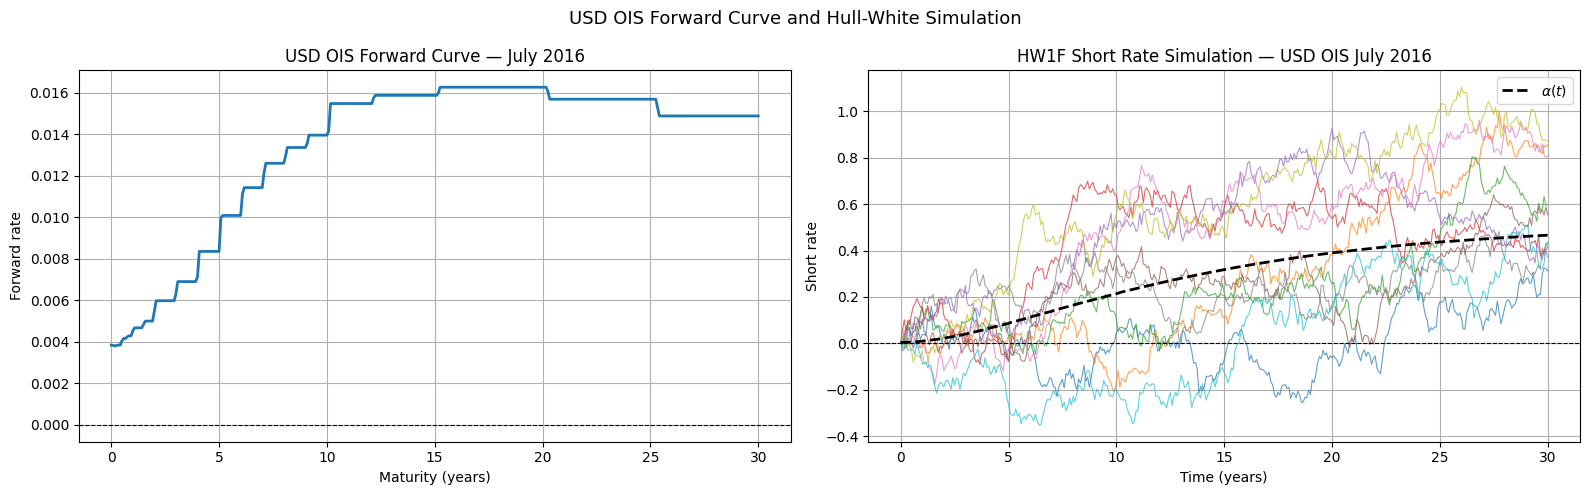

In [106]:
time     = model.time
n_path   = 10
r        = model.generate_path_HW(n_path)
alpha_t  = model.forward_curve + sigma**2/(2*a**2)*(1-np.exp(-a*time))**2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 1. Forward curve ──────────────────────────────────────────────────────────
axes[0].plot(time, model.forward_curve, lw=2)
axes[0].axhline(0, color='black', linestyle='--', lw=0.8)
axes[0].set_xlabel('Maturity (years)')
axes[0].set_ylabel('Forward rate')
axes[0].set_title('USD OIS Forward Curve — July 2016')
axes[0].grid(True)

# ── 2. Simulated paths ────────────────────────────────────────────────────────
axes[1].plot(time, r.T, alpha=0.7, lw=0.8)
axes[1].plot(time, alpha_t, color='black', lw=2, linestyle='--', label=r'$\alpha(t)$')
axes[1].axhline(0, color='black', linestyle='--', lw=0.8)
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Short rate')
axes[1].set_title(r'HW1F Short Rate Simulation — USD OIS July 2016')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('USD OIS Forward Curve and Hull-White Simulation', fontsize=13)
plt.tight_layout()
plt.show()

## Validation — Theoretical Mean vs Monte Carlo Mean

We verify the distributional properties of the simulator by comparing the theoretical conditional mean $\alpha(t)$ with its Monte Carlo estimate. The number of paths is increased to $N = 1000$ to reduce estimation noise.

Conditionally on $\mathcal{F}_0$, the theoretical mean is

$$\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

The Monte Carlo estimator is the sample mean across paths:

$$m^{MC}_N(t) = \frac{1}{N}\sum_{i=1}^{N} r^i(t)$$

By the law of large numbers, $m^{MC}_N(t) \xrightarrow{N \to \infty} \alpha(t)$ almost surely for each $t$. The shaded area between the two curves represents the estimation error

$$\varepsilon_N(t) = \left|m^{MC}_N(t) - \alpha(t)\right|$$

which is expected to decrease at rate $\mathcal{O}(\frac{1}{\sqrt{N}})$ by the central limit theorem. A close agreement between the two curves confirms that the discretization scheme correctly preserves the first moment of the Hull-White distribution.

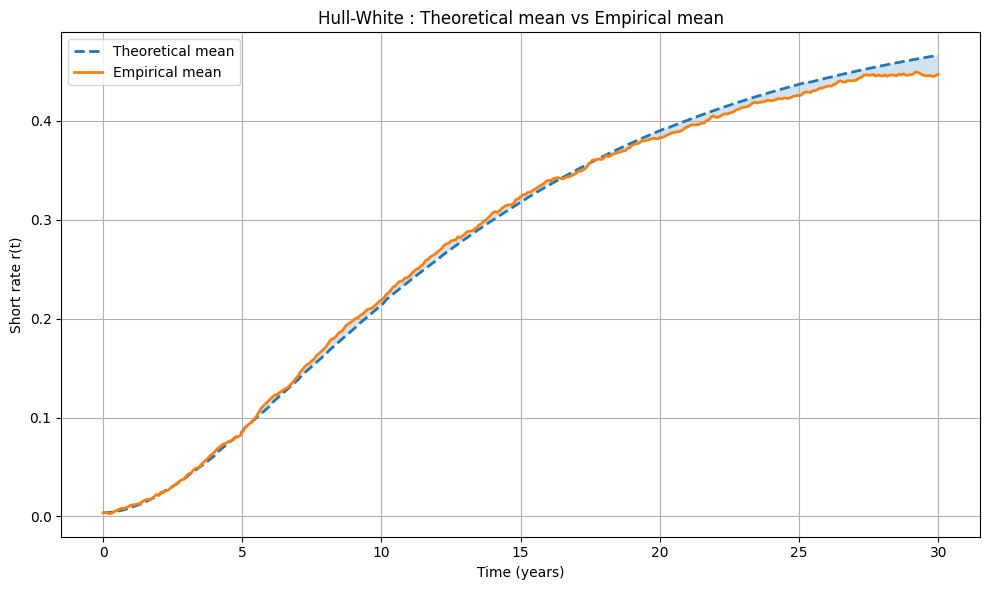

In [70]:

mean_theoretical = model.forward_curve + sigma**2/(2*a**2)*(1-np.exp(-a*time))**2 #alpha_t
# Simulation
n_path = 1000
r = model.generate_path_HW(n_path)
mean_empirical = np.mean(r, axis=0)

# Plot
plt.figure(figsize=(10,6))
plt.plot(time, mean_theoretical, linestyle='--', linewidth=2, label='Theoretical mean')
plt.plot(time, mean_empirical, linewidth=2, label='Empirical mean')

# Zone in between
plt.fill_between(time, mean_theoretical, mean_empirical, alpha=0.2)
plt.title("Hull-White : Theoretical mean vs Empirical mean")
plt.xlabel("Time (years)")
plt.ylabel("Short rate r(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Validation — Theoretical Variance vs Monte Carlo Variance

We similarly validate the second moment of the simulator. The theoretical conditional variance of $r_t$ given $\mathcal{F}_0$ is

$$\mathbb{V}[r_t \mid \mathcal{F}_0] = \frac{\sigma^2}{2a}\left(1 - e^{-2at}\right)$$

which increases monotonically from $0$ at $t=0$ and converges to the stationary variance $\frac{\sigma^2}{2a}$ as $t \to \infty$, reflecting the balance between the diffusion term $\sigma$ and the mean-reversion force $a$.

The Monte Carlo estimator of the variance is the sample variance across paths:

$$V^{MC}_N(t) = \frac{1}{N}\sum_{i=1}^{N}\left(r^i(t) - m^{MC}_N(t)\right)^2$$

By the law of large numbers, $V^{MC}_N(t) \xrightarrow{N \to \infty} \mathbb{V}[r_t \mid \mathcal{F}_0]$ almost surely. A close agreement between the empirical and theoretical curves confirms that the discretization scheme correctly preserves the second moment of the Hull-White distribution, complementing the mean validation above.

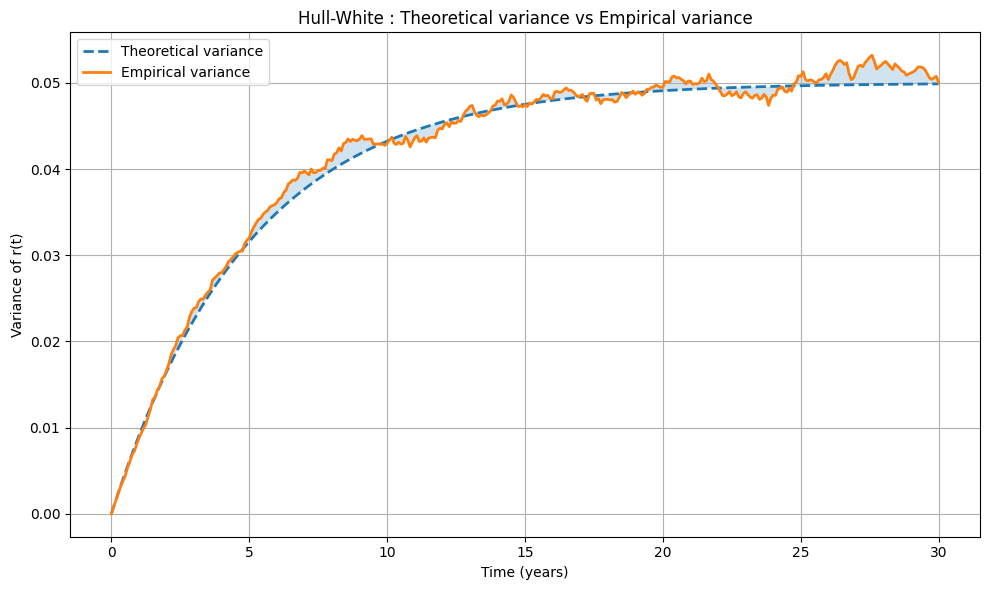

In [71]:

var_theoretical = sigma**2/(2*a) * (1 - np.exp(-2*a*time))
var_empirical = np.var(r, axis=0)

# Plot
plt.figure(figsize=(10,6))
plt.plot(time, var_theoretical, linestyle='--', linewidth=2, label='Theoretical variance')
plt.plot(time, var_empirical, linewidth=2, label='Empirical variance')

# Zone in between
plt.fill_between(time, var_theoretical, var_empirical, alpha=0.2)
plt.title("Hull-White : Theoretical variance vs Empirical variance")
plt.xlabel("Time (years)")
plt.ylabel("Variance of r(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Under the Hull-White model, the price of a zero-coupon bond has a close form formula. The price of such bond is given by
\begin{equation*}
    P(t,T)=\mathbb{E}^Q\Big[e^{-\int_t^Tr_udu}|F_t\Big],
\end{equation*}
where $Q$ is the risk-neutral measure.

Because $r_T$ is normally distributed conditionally to $F_t,\space t<T$, $\int_t^Tr_udu$ is itself normally distributed. We can show that
\begin{equation*}
    \int_t^Tr_udu|F_t\sim\mathcal{N}\bigg(B(t,T)[r_t-\alpha(t)]+\ln\frac{P^M(0,t)}{P^M(0,T)}+\frac{1}{2}[V(0,T)-V(0,t)],V(t,T)\bigg),
\end{equation*}
where
\begin{align*}
    B(t,T) &= \frac{1}{a}\Big(1-e^{-a(T-t)}\Big)\\
    V(t,T)&=\frac{\sigma^2}{a^2}\bigg[T-t+\frac{2}{a}e^{-a(T-t)}-\frac{1}{2a}e^{-2a(T-t)}-\frac{3}{2a}\bigg],
\end{align*}
so that we obtain (see the affine structure)
\begin{equation*}
    P(t,T)=A(t,T)e^{-B(t,T)r_t}
\end{equation*}
with
\begin{align*}
    A(t,T)&=\frac{P^M(0,T)}{P^M(0,t)}\exp\bigg(B(t,T)f^M(0,t)-\frac{\sigma^2}{4a}(1-e^{-2a t})B(t,T)^2\bigg).
\end{align*}

We will use the Monte Carlo approach to approximate the discount factors, keeping the same parameters as above and using that
\begin{equation*}
    P^{MC}(t,T)=\exp\bigg(-\int_t^Tr(u)du|F_t\bigg)\approx \frac{1}{N}\sum_{i=1}^N\exp\bigg(-\sum_{j=1}^{n} r_{t_j}\Delta_t\bigg),
\end{equation*}
with $N=100000$ the number of paths used, $t_1=t=0$ and $t_n=T=30$.

## Zero-Coupon Bond Pricing — Analytical Formula and Monte Carlo Validation

### Analytical Formula

Under the risk-neutral measure $\mathbb{Q}$, the price at time $t$ of a zero-coupon bond maturing at $T$ is defined as

$$P(t,T) = \mathbb{E}^{\mathbb{Q}}\left[e^{-\int_t^T r_u \, du} \,\middle|\, \mathcal{F}_t\right]$$

Since $r_t$ is Gaussian under HW1F, the integral $\int_t^T r_u \, du$ is itself Gaussian conditionally on $\mathcal{F}_t$, with distribution

$$\int_t^T r_u\,du \mid \mathcal{F}_t \sim \mathcal{N}\Big(B(t,T)[r_t-\alpha(t)] + \ln\frac{P^M(0,t)}{P^M(0,T)} + \tfrac{1}{2}[V(0,T)-V(0,t)],\, V(t,T)\Big)$$

where

$$B(t,T) = \frac{1}{a}\left(1 - e^{-a(T-t)}\right), \qquad V(t,T) = \frac{\sigma^2}{a^2}\left[T - t + \frac{2}{a}e^{-a(T-t)} - \frac{1}{2a}e^{-2a(T-t)} - \frac{3}{2a}\right]$$

Exploiting the log-normal moment generating function $\mathbb{E}[e^{-X}] = e^{-\mu + \frac{1}{2}\sigma^2}$ for $X \sim \mathcal{N}(\mu, \sigma^2)$, the bond price takes the **affine form**

$$P(t,T) = A(t,T)\, e^{-B(t,T) r_t}$$

where

$$A(t,T) = \frac{P^M(0,T)}{P^M(0,t)} \exp\left(B(t,T) f^M(0,t) - \frac{\sigma^2}{4a}\left(1 - e^{-2at}\right) B(t,T)^2\right)$$

Note that $A(t,T)$ depends only on market observables $P^M(0,\cdot)$ and the model parameters $(a, \sigma)$, so bond prices are fully determined by the current yield curve and the two parameters — this is the key tractability of affine models.

### Monte Carlo Validation

We validate the analytical formula by comparing it against the Monte Carlo estimator

$$P^{MC}(0,T) = \frac{1}{N} \sum_{i=1}^{N} \exp\left(-\sum_{j=0}^{n-1} r_{t_j} \Delta t\right)$$

with $N = 100{,}000$ paths, $t_0 = 0$, $t_n = T$, and $\Delta t = 1/12$. The inner sum is a Riemann approximation of $\int_0^T r_u \, du$, whose discretization error is $\mathcal{O}(\Delta t)$.

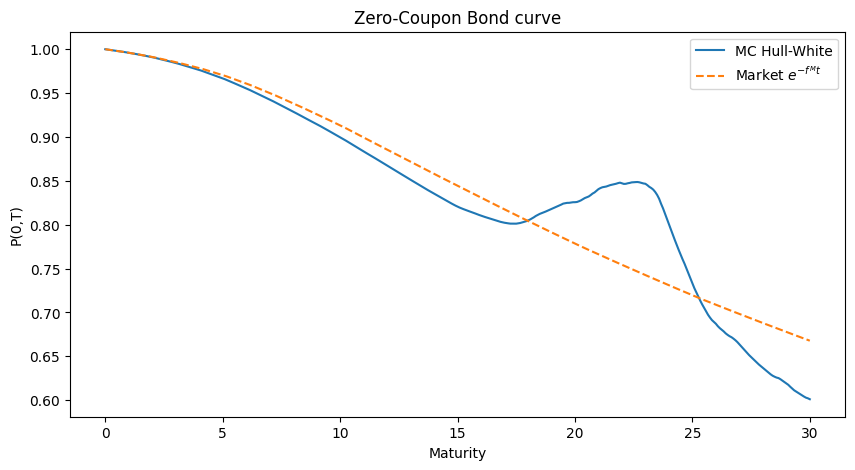

In [76]:
#Monte carlo discount factor
n_path = 100000
r=model.generate_path_HW(n_path)

# P(0, t_i) = E[exp(-int_0^{t_i} r_u du)]
integral_r = np.cumsum(r[:, :-1] * model.dt, axis=1)  # shape (n_path, timestep-1)
discount_paths = np.exp(-integral_r)
MC_discount_factor = np.mean(discount_paths, axis=0)
MC_discount_factor = np.insert(MC_discount_factor, 0, 1)  

# Market discount factors
P_market = model.discount_factor(0,range(0,len(time)))

plt.figure(figsize=(10, 5))
plt.plot(time, MC_discount_factor, label='MC Hull-White')
plt.plot(time, P_market, '--', label='Market $e^{-f^M t}$')
plt.xlabel('Maturity')
plt.ylabel('P(0,T)')
plt.title('Zero-Coupon Bond curve')
plt.legend()
plt.show()

## Monte Carlo Error Analysis — Impact of Volatility

The Monte Carlo estimator of the discount factor is defined as

$$P^{MC}(0,T) = \frac{1}{N}\sum_{i=1}^{N} \exp\left(-\sum_{j=1}^{n} r_{t_j} \Delta t\right)$$

where $N$ is the number of simulated paths and the inner sum approximates $\int_0^T r_u \, du$ by a Riemann sum over the discretized grid.

The Monte Carlo error is defined path-wise as

$$\varepsilon(T) = \left|P^{MC}(0,T) - P^{M}(0,T)\right|$$

where $P^{M}(0,T) = e^{-f^M \cdot T}$ is the market discount factor under a flat forward rate assumption.

Under the Hull-White model, the short rate $r_t$ has conditional variance

$$\mathbb{V}[r_t | \mathcal{F}_0] = \frac{\sigma^2}{2a}\left(1 - e^{-2at}\right)$$

which increases with $\sigma$ and converges to $\frac{\sigma^2}{2a}$ as $t \to \infty$. A higher volatility $\sigma$ therefore induces wider dispersion of short rate paths, which in turn increases the variance of the Monte Carlo estimator and degrades convergence.

This is confirmed in the figure below, where the cumulative absolute error $\sum_{T} \varepsilon(T)$ is plotted as a function of maturity for several values of $\sigma$. As $\sigma$ decreases toward zero, the short rate paths collapse toward the deterministic mean $\alpha(t)$ and the Monte Carlo discount factors converge to the market curve.

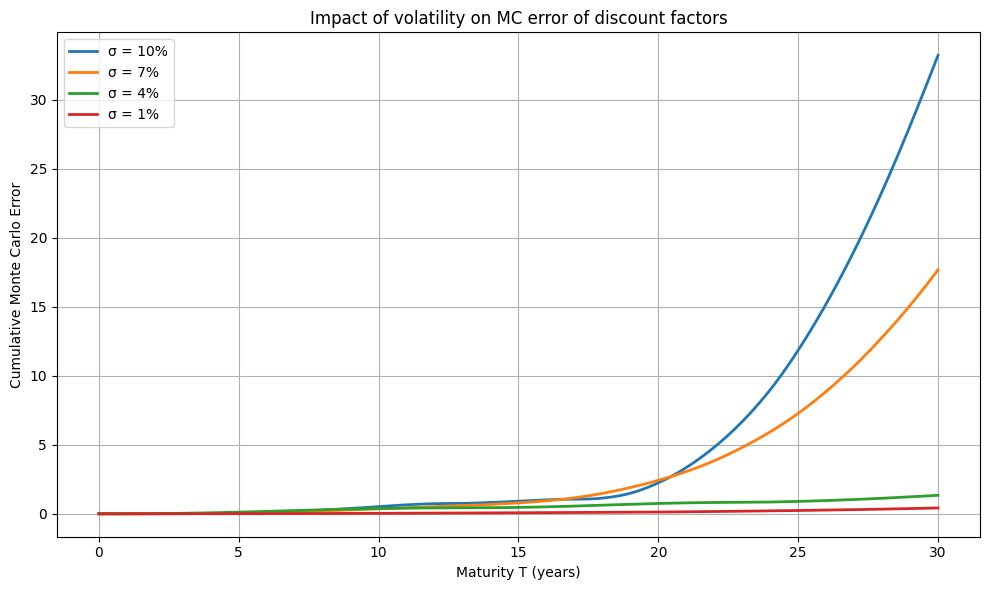

In [78]:
# Monte Carlo parameters
n_path = 10000

# Hull-White parameters
a = 0.1

# Volatility values to test
sigma_values = [0.10, 0.07, 0.04, 0.01]

# Generate Hull-White paths for each volatility
r_paths_list = []
for sigma in sigma_values:
    model.sigma = sigma
    # Generate paths
    r_paths = model.generate_path_HW(n_path)
    r_paths_list.append(r_paths)

# Compute Monte Carlo discount factors
MC_discount_factors = [
    np.insert(np.mean(np.exp(-np.cumsum(r[:, :-1]*model.dt, axis=1)), axis=0), 0, 1)
    for r in r_paths_list
]

# Market discount factors
P_market = model.discount_factor(0,range(0,len(time)))

# Compute cumulative absolute error for each volatility
err_list = [np.cumsum(np.abs(P_market - MC_df)) for MC_df in MC_discount_factors]

# Plot
plt.figure(figsize=(10,6))
labels = [f'σ = {sigma*100:.0f}%' for sigma in sigma_values]

for err, label in zip(err_list, labels):
    plt.plot(time, err, label=label, linewidth=2)

plt.xlabel('Maturity T (years)')
plt.ylabel('Cumulative Monte Carlo Error')
plt.title('Impact of volatility on MC error of discount factors')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Monte Carlo Error Analysis — Impact of Mean-Reversion Speed

Recall that under the Hull-White model, the conditional variance of the short rate is given by

$$\mathbb{V}[r_t | \mathcal{F}_0] = \frac{\sigma^2}{2a}\left(1 - e^{-2at}\right)$$

Two competing effects arise as $a$ increases:

- **Short-term**: a higher $a$ pulls paths more aggressively toward the mean $\alpha(t)$, reducing dispersion at short maturities
- **Long-term**: the stationary variance $\frac{\sigma^2}{2a}$ decreases as $a$ increases, so paths are more tightly concentrated around $\alpha(t)$ at all horizons

As a consequence, a higher mean-reversion speed $a$ reduces the variance of the Monte Carlo estimator

$$P^{MC}(0,T) = \frac{1}{N}\sum_{i=1}^{N} \exp\left(-\sum_{j=1}^{n} r_{t_j} \Delta t\right)$$

and therefore improves convergence toward the market discount curve $P^M(0,T) = e^{-f^M \cdot T}$.

This can be understood intuitively: a high mean-reversion speed prevents the short rate from drifting far from its long-run level, which keeps the simulated discount factors close to their theoretical values. In the limit $a \to \infty$, the short rate is instantly pulled back to $\alpha(t)$ and all paths become deterministic.

The figure below plots the cumulative absolute error $\sum_T |P^{MC}(0,T) - P^M(0,T)|$ for several values of $a$, with $\sigma$ held constant. The monotone decrease in error with increasing $a$ confirms the theoretical prediction.

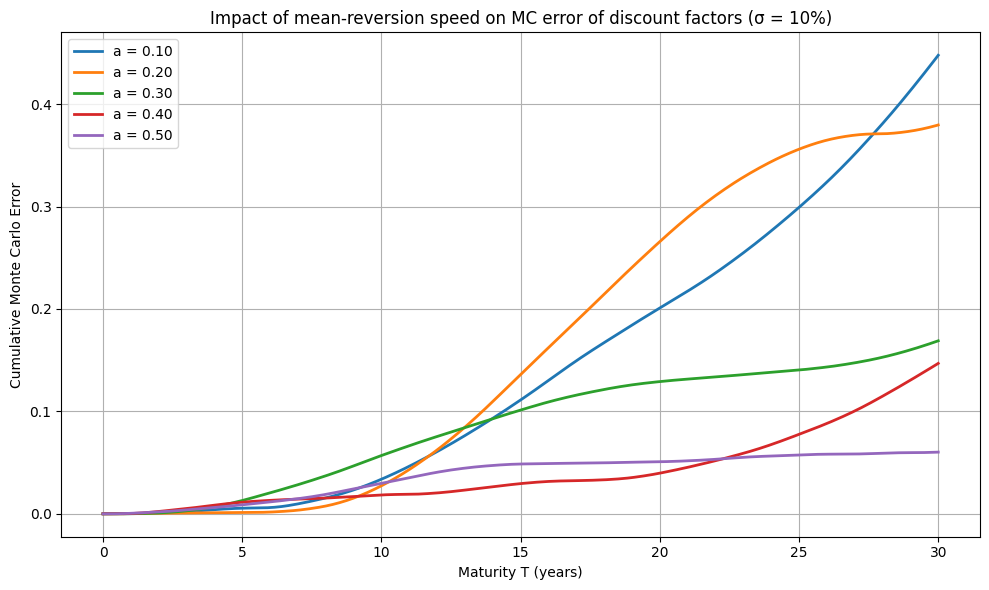

In [79]:
# Monte Carlo parameters
n_path = 10000
sigma = 0.1
forward_rate = 0.02

# Varying mean-reversion speed 'a'
a_values = [0.10, 0.20, 0.30, 0.40, 0.50]

# Generate Hull-White paths for each 'a'
r_paths_list = []
for a in a_values:
    model.a = a
    r_paths = model.generate_path_HW(n_path)
    r_paths_list.append(r_paths)

# Compute Monte Carlo discount factors
MC_discount_factors = [
    np.insert(np.mean(np.exp(-np.cumsum(r[:, :-1] * model.dt, axis=1)), axis=0), 0, 1)
    for r in r_paths_list
]

# Market discount factors
P_market = model.discount_factor(0,range(0,len(time)))

# Compute cumulative absolute error for each 'a'
err_list = [np.cumsum(np.abs(P_market - MC_df)) for MC_df in MC_discount_factors]

# Plot
plt.figure(figsize=(10,6))
labels = [f'a = {a_val:.2f}' for a_val in a_values]
for err, label in zip(err_list, labels):
    plt.plot(time, err, label=label, linewidth=2)

plt.xlabel('Maturity T (years)')
plt.ylabel('Cumulative Monte Carlo Error')
plt.title(f'Impact of mean-reversion speed on MC error of discount factors (σ = {sigma*100:.0f}%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## European Bond Options — Jamshidian's Formula

### Pricing under Hull-White

The price at time $t$ of a European option with strike $K$, expiry $T$, and $\omega = 1$ for a call ($\omega = -1$ for a put) on a zero-coupon bond maturing at $S > T$ is defined as

$$\textbf{ZBO}(t,T,S,K,\omega) = \mathbb{E}^{\mathbb{Q}}\left[e^{-\int_t^T r_u \, du}\left(\omega(P(T,S) - K)\right)_+\,\middle|\,\mathcal{F}_t\right]$$

Since $P(T,S) = A(T,S)e^{-B(T,S)r_T}$ is a monotone decreasing function of the Gaussian variable $r_T$, the bond price $P(T,S)$ is log-normally distributed conditionally on $\mathcal{F}_t$. This allows for an exact closed-form solution, derived by Jamshidian (1989) in his article *"An Exact Bond Option Formula"*:

$$\textbf{ZBO}(t,T,S,K,\omega) = \omega\left[P(t,S)\,\Phi(\omega h) - K\,P(t,T)\,\Phi\left(\omega(h-\sigma_p)\right)\right]$$

where

$$\sigma_p = \sigma\sqrt{\frac{1-e^{-2a(T-t)}}{2a}}\,B(T,S), \qquad h = \frac{1}{\sigma_p}\ln\frac{P(t,S)}{P(t,T)K} + \frac{\sigma_p}{2}, \qquad B(T,S) = \frac{1-e^{-a(S-T)}}{a}$$

### Interpretation

The formula is structurally identical to Black-Scholes, with:
- $P(t,S)$ playing the role of the forward asset price, discounted to $t$
- $K \cdot P(t,T)$ playing the role of the discounted strike
- $\sigma_p$ playing the role of the total implied volatility of $P(T,S)$

In particular, $\sigma_p$ captures both the uncertainty of the short rate over $[t,T]$ via the term $\sqrt{\frac{1-e^{-2a(T-t)}}{2a}}$, and the sensitivity of the bond price to the short rate via $B(T,S)$. A higher mean-reversion speed $a$ reduces $\sigma_p$ through both channels, dampening option prices.

### Monte Carlo Validation

We validate the formula against a Monte Carlo estimate with $N = 100{,}000$ paths, plotting the running average

$$\widehat{V}^{MC}_N = \frac{1}{N}\sum_{i=1}^{N} e^{-\int_0^T r^i_u \, du} \left(\omega(P^i(T,S) - K)\right)_+$$

as a function of $N$ to illustrate convergence toward the analytical price.

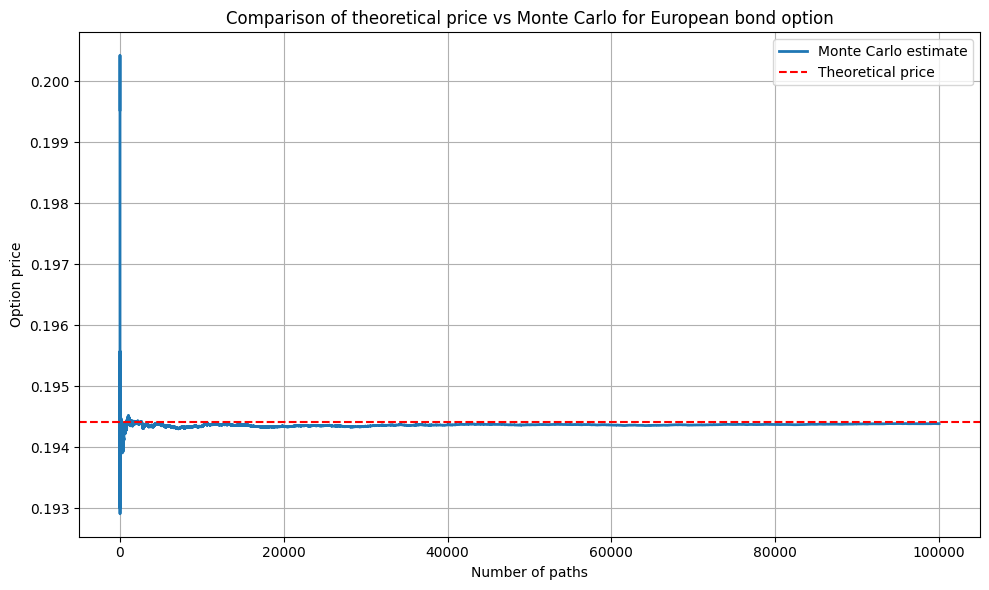

In [80]:
# Option parameters
t_idx = 0       # option evaluation at t0
T_idx = 12      # option maturity index
S_idx = 24      # bond maturity index
K = 0.80        # strike
omega = 1       # call option

# Compute theoretical price using Jamshidian formula (via class)
theoretical_price_call_option = model.price_european_bond_option_HW(t_idx, T_idx, S_idx, K, omega)

# Monte Carlo parameters
n_path = 100000

# Generate Hull-White short rate paths
r_paths = model.generate_path_HW(n_path)

# Compute discount factors along each path
discount_T_S = model.discount_factor_HW(T_idx, S_idx, r_paths)
discount_t_T = model.discount_factor_HW(t_idx, T_idx, r_paths)
# Option payoff path by path
payoff_paths = discount_t_T * np.maximum(discount_T_S - K, 0)

# Monte Carlo estimate: running average over paths
MC_price_call_option = np.cumsum(payoff_paths) / np.arange(1, n_path+1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(np.arange(1, n_path+1), MC_price_call_option, label='Monte Carlo estimate', linewidth=2)
plt.axhline(theoretical_price_call_option, color='red', linestyle='--', label='Theoretical price')
plt.xlabel('Number of paths')
plt.ylabel('Option price')
plt.title('Comparison of theoretical price vs Monte Carlo for European bond option')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Price Surface of a European Bond Option

We study how the price of a European call option on a zero-coupon bond varies 
jointly with the strike $K$ and the volatility $\sigma$, holding fixed:

$$t = 0, \quad T = 1\text{Y}, \quad S = 2\text{Y}, \quad a = 0.1, \quad f^M = 5\%$$

**Along the strike axis**: the call price decreases monotonically — a higher 
strike makes the option less likely to finish in the money. The ATM forward 
strike $K^* = P(0,S)/P(0,T)$ is the natural reference separating ITM from OTM.

**Along the volatility axis**: the price increases with $\sigma$ — wider 
dispersion of $r_T$ increases the probability of large moves in $P(T,S)$. 
This is the standard vega effect, here driven entirely by short rate volatility.

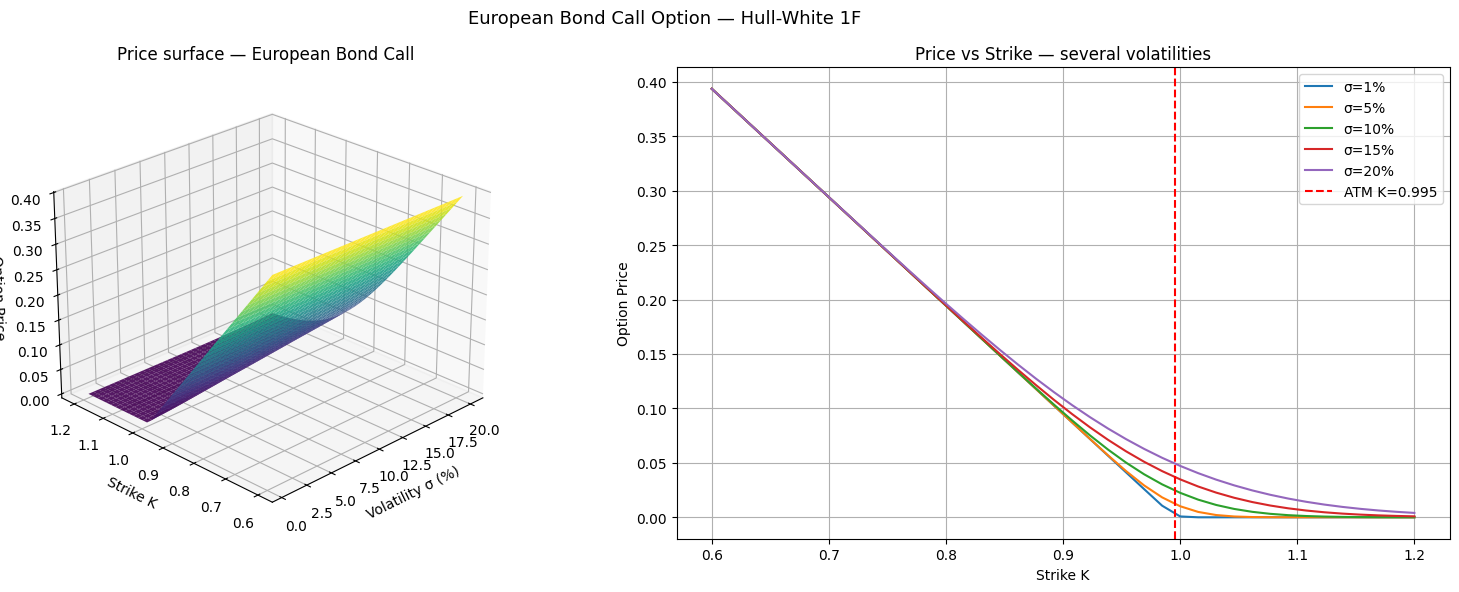

In [81]:

# Option parameters
t_idx = 0
T_idx = 12
S_idx = 24
omega = 1  # Call option, -1 for a put

# Vol and strike
sigma_range = np.linspace(0.005, 0.20, 40)
K_range = np.linspace(0.6, 1.2, 40)
Sigma, K_grid = np.meshgrid(sigma_range, K_range)
Price = np.zeros_like(Sigma)

# Price of the european bond option for each strike and vol
for i in range(Sigma.shape[0]):
    for j in range(Sigma.shape[1]):
        model.sigma = Sigma[i,j]
        Price[i,j] = model.price_european_bond_option_HW(t_idx, T_idx, S_idx,K_grid[i,j],omega)


fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(Sigma * 100, K_grid, Price, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Volatility σ (%)')
ax1.set_ylabel('Strike K')
ax1.set_zlabel('Option Price')
ax1.set_title('Price surface — European Bond Call')
ax1.view_init(elev=25, azim=-135)


ax2 = fig.add_subplot(122)
P_t_S = model.discount_factor(0, S_idx)
P_t_T = model.discount_factor(0, T_idx)
K_atm = P_t_S / P_t_T


sigma_levels = [0.01, 0.05, 0.10, 0.15, 0.20]
for s in sigma_levels:
    prices = []
    for k in K_range:
        model.sigma = s
        prices.append(model.price_european_bond_option_HW(t_idx, T_idx, S_idx, k, omega))
    ax2.plot(K_range, prices, label=f'σ={s*100:.0f}%')

ax2.axvline(K_atm, color='red', linestyle='--', lw=1.5, label=f'ATM K={K_atm:.3f}')
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Option Price')
ax2.set_title('Price vs Strike — several volatilities')
ax2.legend()
ax2.grid(True)

plt.suptitle('European Bond Call Option — Hull-White 1F', fontsize=13)
plt.tight_layout()
plt.show()



## Swaption Volatility Calibration

### Market Data and Objective

We calibrate the Hull-White parameters $(a, \sigma)$ to a set of 5 ATM swaption 
quotes, covering a diagonal of the swaption volatility surface. Market data is 
from July 2016, a period of historically low rates where lognormal implied 
volatilities were elevated:

| Expiry $T$ | Tenor | Log Vol |
|:---:|:---:|:---:|
| 1Y | 5Y | 49.77% |
| 2Y | 4Y | 50.94% |
| 3Y | 3Y | 51.43% |
| 4Y | 2Y | 51.77% |
| 5Y | 1Y | 53.39% |

For each instrument, the ATM strike is set to the par swap rate

$$K_i = S(T_i, T_i + \delta_i) = \frac{P(0, T_i) - P(0, T_i + \delta_i)}{\sum_{j} \tau_j P(0, t_j)}$$

The market price is computed via Black's formula for swaptions:

$$V^{mkt}_i = A_i \cdot \left[S_i \cdot \Phi(d_1) - K_i \cdot \Phi(d_2)\right]$$

where $A_i = \sum_j \tau_j P(0, t_j)$ is the annuity factor and $\sigma^{Black}_i \sqrt{T_i}$ is the total implied volatility.

The model price is computed via the Jamshidian decomposition:

$$V^{model}_i = \sum_{j} c_j \cdot \textbf{ZBO}(0, T_i, t_j, K_j^*, -\omega)$$

where $K_j^* = A(T_i, t_j)e^{-B(T_i, t_j)r^*}$ and $r^*$ solves $\sum_j c_j P(T_i, t_j, r^*) = 1$.

### Calibration Problem

The parameters $(a, \sigma)$ are found by minimizing the sum of squared price differences:

$$\min_{a,\, \sigma > 0} \sum_{i=1}^{5} \left(V^{mkt}_i - V^{model}_i(a, \sigma)\right)^2$$

### Limitations

HW1F with constant $\sigma$ generates a **decreasing vol term structure**, 
whereas the market surface shows a mildly increasing structure (49.77% → 53.39%). 
This structural mismatch means the model will systematically overprice short 
maturities and underprice long maturities — a limitation that a time-dependent 
$\sigma(t)$ or a richer model such as SABR-LMM would resolve.

In [95]:
CalibrationData = {"maturity":12*np.array([1,2,3,4,5]), "tenor":12*np.array([5,4,3,2,1]), "volatility":[0.497732,0.509427, 0.514257, 0.517659, 0.533874]}
import pandas as pd

def objective(params):
    a, sigma = params
    model.a = a
    model.sigma = sigma
    error = 0
    for i in range(len(CalibrationData["maturity"])):
        maturity   = CalibrationData["maturity"][i]
        tenor      = CalibrationData["tenor"][i]
        vol        = CalibrationData["volatility"][i]
        strike     = model.swap_rate(0,maturity,tenor)
        market_price = model.swaption_black(strike, vol, maturity, tenor, omega=1)
        model_price  = model.swaption_Jamshidian(maturity, tenor, strike, omega=1)
        error += (market_price - model_price)**2
    return error

result = minimize(objective, 
                  x0=[0.01, 0.01],           # initial guess
                  bounds=[(1e-4, 1.0), (1e-4, 0.1)])

a_cal, sigma_cal = result.x
print(f"Calibrated a     = {a_cal:.5f}")
print(f"Calibrated sigma = {sigma_cal:.5f}")
# rapport
model.calibration_report(CalibrationData)

Calibrated a     = 0.01317
Calibrated sigma = 0.00417
         Model Price  Market Price  Model Vol  Market Vol  Error Price  Error Vol
1Y x 5Y     0.007824      0.006886     0.5673      0.4977     0.000938     0.0696
2Y x 4Y     0.008831      0.008511     0.5295      0.5094     0.000320     0.0200
3Y x 3Y     0.008088      0.008386     0.4948      0.5143    -0.000298    -0.0195
4Y x 2Y     0.006205      0.006977     0.4560      0.5177    -0.000771    -0.0617
5Y x 1Y     0.003455      0.004314     0.4182      0.5339    -0.000859    -0.1156

Cumulated error price : 0.003186
Cumulated error vol   : 0.2864


## Calibration with Fixed Mean-Reversion Speed

A well-known limitation of HW1F is that the two parameters $(a, \sigma)$ are 
difficult to identify simultaneously from swaption prices alone, as many pairs 
$(a, \sigma)$ produce nearly identical prices — as illustrated by the price surface above.

In practice, the mean-reversion speed $a$ is therefore fixed exogenously, typically 
from historical estimation or market convention, and only $\sigma$ is calibrated to 
match market prices. We fix $a = 5\%$, a standard choice for short-to-medium 
maturity swaptions, and calibrate $\sigma$ by minimizing the sum of squared price 
differences:

$$\min_{\sigma > 0} \sum_{i=1}^{5} \left(V^{mkt}_i - V^{model}_i(\sigma)\right)^2$$

This reduces the problem to a **one-dimensional optimization**, which is convex and 
has a unique solution, eliminating the instability observed in the joint calibration.

In [96]:
model.a = 0.05 #Fix reversion speed
def objective(params):
    model.sigma = params
    error = 0
    for i in range(len(CalibrationData["maturity"])):
        maturity   = CalibrationData["maturity"][i]
        tenor      = CalibrationData["tenor"][i]
        vol        = CalibrationData["volatility"][i]
        strike     = model.swap_rate(0,maturity,tenor)
        market_price = model.swaption_black(strike, vol, maturity, tenor, omega=1)
        model_price  = model.swaption_Jamshidian(maturity, tenor, strike, omega=1)
        error += (market_price - model_price)**2
    return error
result = minimize(objective, 
                  x0=[0.01],# initial guess
                  bounds=[(1e-4, 0.1)])
sigma_cal = result.x[0]
print(f"Fixed reversion speed a = {model.a}")
print(f"Calibrated sigma = {sigma_cal:.5f}")
model.calibration_report(CalibrationData)

Fixed reversion speed a = 0.05
Calibrated sigma = 0.00464
         Model Price  Market Price  Model Vol  Market Vol  Error Price  Error Vol
1Y x 5Y     0.007825      0.006886     0.5673      0.4977     0.000939     0.0696
2Y x 4Y     0.008827      0.008511     0.5293      0.5094     0.000317     0.0199
3Y x 3Y     0.008086      0.008386     0.4947      0.5143    -0.000300    -0.0196
4Y x 2Y     0.006209      0.006977     0.4562      0.5177    -0.000768    -0.0614
5Y x 1Y     0.003462      0.004314     0.4191      0.5339    -0.000852    -0.1148

Cumulated error price : 0.003176
Cumulated error vol   : 0.2853


## Swaption Price Surface and Identification Problem — Joint Effect of $\sigma$ and $a$

We plot the swaption price and the squared calibration error as a function of both 
the volatility $\sigma$ and the mean-reversion speed $a$, holding the strike, 
maturity and tenor fixed (1Y $\times$ 5Y ATM payer swaption).

**Price surface.** The price increases with $\sigma$ (higher short rate volatility 
widens the distribution of future rates, increasing option value) and decreases 
with $a$ (stronger mean reversion compresses the distribution, reducing option value). 
Many $(a, \sigma)$ pairs produce the same swaption price — the iso-price curves 
form ridges running diagonally across the surface.

**Error surface.** The squared price error

$$\mathcal{L}(a, \sigma) = \left(V^{mkt} - V^{model}(a, \sigma)\right)^2$$

reveals a clear **valley structure** — a continuous ridge of $(a, \sigma)$ pairs 
that all achieve a near-zero error. This is the geometric manifestation of the 
identification problem: the gradient of $\mathcal{L}$ is nearly zero along this 
ridge, so any gradient-based optimizer will converge to whichever point it first 
reaches, depending entirely on the initial guess. The sharp peak visible for large 
$a$ and large $\sigma$ simultaneously corresponds to a region where the two 
parameters over-compensate each other, producing a model price far from the market.

This surface provides a clear visual justification for the standard market practice 
of **fixing $a$ exogenously** and calibrating $\sigma$ alone — fixing $a$ amounts 
to taking a slice along a fixed $a$ value, reducing the problem to a 
**one-dimensional convex optimization** with a unique minimum.

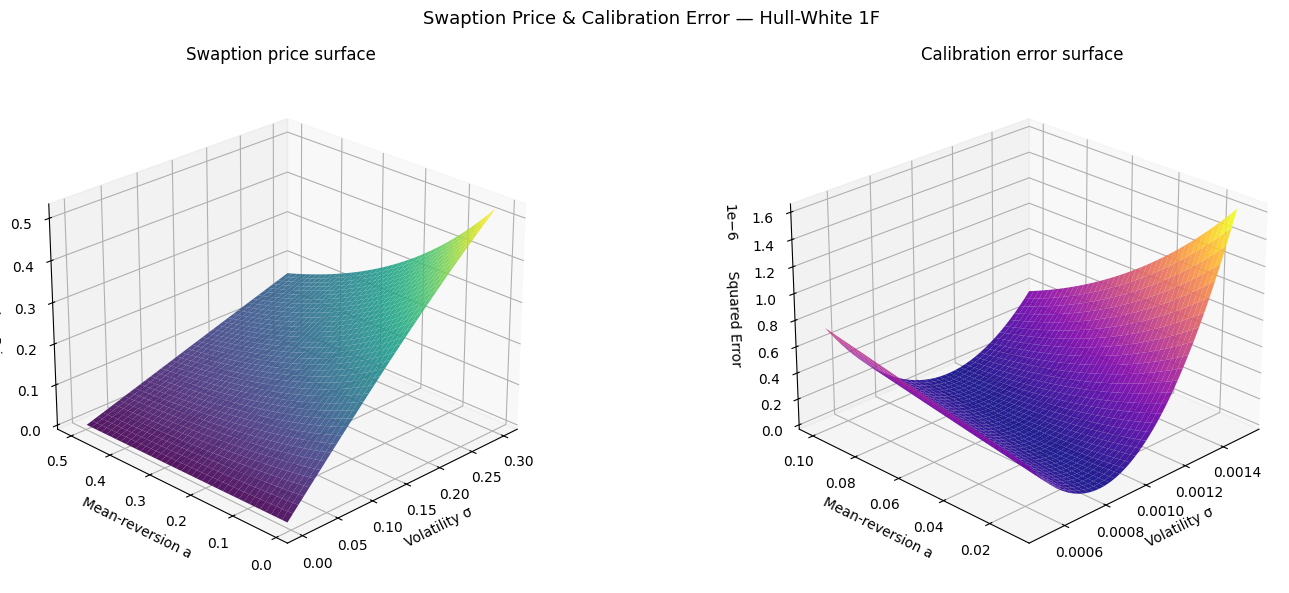

In [85]:
sigma_range = np.linspace(0.001,0.3,40)
a_range = np.linspace(0.01,0.5,40)
maturity = 12
tenor = 60
fig = plt.figure(figsize=(16, 6))

# ── 1. Price surface ──────────────────────────────────────────────────────────
sigma_range = np.linspace(0.001, 0.3, 40)
a_range     = np.linspace(0.01, 0.5, 40)
sigma, a    = np.meshgrid(sigma_range, a_range)
strike      = model.swap_rate(0, maturity, tenor)
Price       = np.zeros_like(sigma)

for i in range(sigma.shape[0]):
    for j in range(sigma.shape[1]):
        model.a     = a[i][j]
        model.sigma = sigma[i][j]
        Price[i][j] = model.swaption_Jamshidian(maturity, tenor, strike, 1)

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(sigma, a, Price, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Volatility σ')
ax1.set_ylabel('Mean-reversion a')
ax1.set_zlabel('Swaption Price')
ax1.set_title('Swaption price surface')
ax1.view_init(elev=25, azim=-135)

# ── 2. Error surface ──────────────────────────────────────────────────────────
sigma_range = np.linspace(sigma_cal-sigma_cal/2, sigma_cal+sigma_cal/2, 40)
a_range     = np.linspace(0.01, 0.1, 40)
sigma, a    = np.meshgrid(sigma_range, a_range)
Errors      = np.zeros_like(sigma)
market_price = model.swaption_black(strike, CalibrationData["volatility"][0], maturity, tenor, 1)

for i in range(sigma.shape[0]):
    for j in range(sigma.shape[1]):
        model.a     = a[i][j]
        model.sigma = sigma[i][j]
        p           = model.swaption_Jamshidian(maturity, tenor, strike, 1)
        Errors[i][j] = (p - market_price) ** 2

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(sigma, a, Errors, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_xlabel('Volatility σ')
ax2.set_ylabel('Mean-reversion a')
ax2.set_zlabel('Squared Error')
ax2.set_title('Calibration error surface')
ax2.view_init(elev=25, azim=-135)

plt.suptitle('Swaption Price & Calibration Error — Hull-White 1F', fontsize=13)
plt.tight_layout()
plt.show()


## Constant-Maturity Swaps (CMS)

### Product Description

A **Constant-Maturity Swap (CMS)** is a variant of a standard interest rate swap in which one leg pays, at each payment date $T_i$, the **$c$-year swap rate resetting at $T_{i-1}$**, rather than a fixed rate or IBOR. Formally, institution $A$ pays to $B$ at time $T_i$:

$$S_{i-1,\,i-1+c}(T_{i-1})\cdot\tau_i$$

where $S_{\alpha,\beta}(t)$ is the forward swap rate at time $t$:

$$S_{\alpha,\beta}(t) = \frac{P(t,T_\alpha)-P(t,T_\beta)}{\sum_{k=\alpha+1}^{\beta}\tau_k P(t,T_k)}.$$

The difficulty in pricing the CMS floating leg lies in computing, for each payment date $T_{i+1}$:

$$\mathbb{E}\big[D(0,T_{i+1})\,\tau_{i+1}\,S_{i,i+c}(T_i)\big] = \tau_{i+1}\,P(0,T_{i+1})\,\mathbb{E}^{T_{i+1}}\big[S_{i,i+c}(T_i)\big].$$

The swap rate is a martingale under its **swap measure** $Q^{\alpha,\beta}$, not under the **forward measure** $Q^{T_{i+1}}$. The change of numeraire introduces a **convexity adjustment**.

---

### The Convexity Adjustment — Brigo & Mercurio (2nd method)

Following Brigo & Mercurio, we use the approximation that drops the notional reimbursement in the flat-curve proxy. Define

$$\Psi_{\alpha,\beta}(y) := S_{\alpha,\beta}(0)\sum_{i=\alpha+1}^{\beta}\tau_i\frac{P(0,T_\alpha)}{(1+y)^{\tau_{\alpha,i}}},$$

and assume $\mathbb{E}^{T}[\Psi(S_{\alpha,\beta}(T)) - \Psi(S_{\alpha,\beta}(0))] \approx 0$. A second-order Taylor expansion then yields the classic formula:

$$\boxed{\mathbb{E}^{T_{i+1}}\big[S_{i,i+c}(T_i)\big] \approx S_{i,i+c}(0) - \frac{1}{2}S_{i,i+c}(0)^2\,v_{i,i+c}^2(T_i)\,\frac{\Psi_{i,i+c}''(S_{i,i+c}(0))}{\Psi_{i,i+c}'(S_{i,i+c}(0))}}$$

where $v_{i,i+c}^2(T_i) = \int_0^{T_i}\sigma^{(i,i+c)}(t)^2\,dt$ is the integrated variance of the forward swap rate, read from the swaption volatility surface.

In practice, for each CMS coupon at $T_{i+1}$:
- $S_{i,i+c}(0)$ is the at-the-money forward swap rate,
- $v_{i,i+c}$ is the Black implied vol for the $(T_i \times c)$ swaption,
- $\Psi'$ and $\Psi''$ are computed numerically via central finite differences.

The full value of the CMS floating leg is then:

$$V_{\text{float}} = \sum_{i=1}^{n} \tau_i\,P(0,T_i)\,\mathbb{E}^{T_i}\big[S_{i-1,i-1+c}(T_{i-1})\big].$$


In [86]:
# Load swaption volatility surface (in bps)
df = pd.read_excel("Market Data/swaption vol surface interpolated.xlsx", index_col=0, header=0)
swaption_surface = df.values

# ── 1. CMS Floating Leg — varying swap tenor, 5Y payment schedule ───────────
cms_maturity = 60   # 5-year payment schedule (monthly steps)
tenors       = [12, 24, 36, 60, 120]  # 1Y, 2Y, 3Y, 5Y, 10Y CMS

print(f"{'Swap tenor':<14} {'Fwd Swap Rate (bps)':>20} {'CMS Float Leg (bps)':>22}")
print("-" * 58)
for swap_tenor in tenors:
    price   = model.constant_maturity_swap(cms_maturity, swap_tenor, swaption_surface, period=12)
    sr      = model.swap_rate(0, 0, swap_tenor, period=12) * 1e4
    print(f"  CMS {cms_maturity//12}Y x {swap_tenor//12}Y    {sr:>20.2f} {price*1e4:>22.4f}")

# ── 2. Coupon-level convexity adjustments — 5Yx5Y CMS ──────────────────────
print()
print("Convexity adjustment per coupon — 5Y CMS on 5Y swap rate")
print(f"{'Payment date':<15} {'Naive coupon (bps)':>20} {'Convexity adj (bps)':>22}")
print("-" * 58)
swap_tenor   = 60
time_arr     = np.array(model.time)
for payment_date in [12, 24, 36, 48, 60]:
    resetting_date = payment_date - 12
    tau  = time_arr[payment_date] - time_arr[resetting_date]
    disc = model.discount_factor(0, payment_date)
    sr   = model.swap_rate(0, resetting_date, swap_tenor, period=12)
    naive = tau * disc * sr * 1e4
    if resetting_date == 0:
        adj = 0.0
    else:
        full  = model.constant_maturity_swap_coupon(payment_date, swap_tenor, swaption_surface, period=12)
        adj   = (full - tau * disc * sr) * 1e4
    print(f"  T = {payment_date//12}Y         {naive:>20.4f} {adj:>22.4f}")




Swap tenor      Fwd Swap Rate (bps)    CMS Float Leg (bps)
----------------------------------------------------------
  CMS 5Y x 1Y                   40.26               296.0929
  CMS 5Y x 2Y                   44.25               325.9570
  CMS 5Y x 3Y                   49.34               357.6610
  CMS 5Y x 5Y                   59.83               421.8686
  CMS 5Y x 10Y                   90.27               555.8035

Convexity adjustment per coupon — 5Y CMS on 5Y swap rate
Payment date      Naive coupon (bps)    Convexity adj (bps)
----------------------------------------------------------
  T = 1Y                      59.5922                 0.0000
  T = 2Y                      71.0684                 0.2918
  T = 3Y                      83.4700                 0.7180
  T = 4Y                      95.7531                 1.3217
  T = 5Y                     107.5496                 2.1039


## Caps and Floors under Hull-White

A cap can be decomposed into a portfolio of zero-coupon put options — one per 
caplet — via the identity

$$\textbf{Cap}(t, \mathcal{T}, N, K) = \sum_{i=1}^n N(1+\tau_i K)\cdot\textbf{ZBP}\!\left(t,\, t_{i-1},\, t_i,\, \frac{1}{1+\tau_i K}\right)$$

Under HW1F, each **ZBP** is priced in closed form via Jamshidian's formula, 
making the cap price fully analytical.

### Cap-Floor Parity

As a first validation, we verify the model-free identity

$$\textbf{Cap}(K) - \textbf{Flr}(K) = \textbf{Swap}(K)$$

which follows caplet by caplet from $(x)_+ - (-x)_+ = x$. Any numerical 
violation would indicate an implementation error rather than a model limitation.

In [89]:
test_cases = [
    (0,   12, 0.02),
    (6,   12, 0.02),
    (12,   36, 0.03),
    (12,   60, 0.04),
    (12,  120, 0.05),
    (12,   60, 0.00),
]

data = []
for t_idx, T_mat, K in test_cases:
    cf   = model.cap_Jamshidian(0, t_idx, T_mat, K) - model.floor_Jamshidian(0, t_idx, T_mat, K)
    swap = model.swap(0, t_idx, T_mat, 1, K)
    data.append({
        "Cap"    : f"{t_idx//3 * 3 / 12}Y x {T_mat//12}Y",
        "Strike" : f"{K*100}%",
        "Cap - Floor" : round(cf,   8),
        "Swap"        : round(swap, 8),
        "Error"       : f"{abs(cf - swap):.2e}"
    })

df_parity = pd.DataFrame(data).set_index("Cap")
print(df_parity.to_string())

           Strike  Cap - Floor      Swap     Error
Cap                                               
0.0Y x 1Y    2.0%    -0.015941 -0.015941  4.65e-16
0.5Y x 1Y    2.0%    -0.015498 -0.015498  5.46e-16
1.0Y x 3Y    3.0%    -0.071464 -0.071464  8.47e-16
1.0Y x 5Y    4.0%    -0.160961 -0.160961  1.67e-16
1.0Y x 10Y   5.0%    -0.380952 -0.380952  2.16e-15
1.0Y x 5Y    0.0%     0.035037  0.035037  1.60e-16


As $\sigma \to 0$, the cap price converges to its intrinsic value — the 
discounted payoff $(S_{ATM} - K)_+$, which is purely deterministic. 
As $\sigma$ increases, the price rises across all strikes, but the effect 
is most pronounced **in the money**: deep ITM caps are almost insensitive 
to $\sigma$ (their payoff is near-certain regardless), while near-the-money 
caps exhibit maximum vega. For large $\sigma$, the price profile flattens 
into an almost **affine function of the strike** — the optionality vanishes 
as all caplets become likely to pay, and the cap behaves like a floating leg.

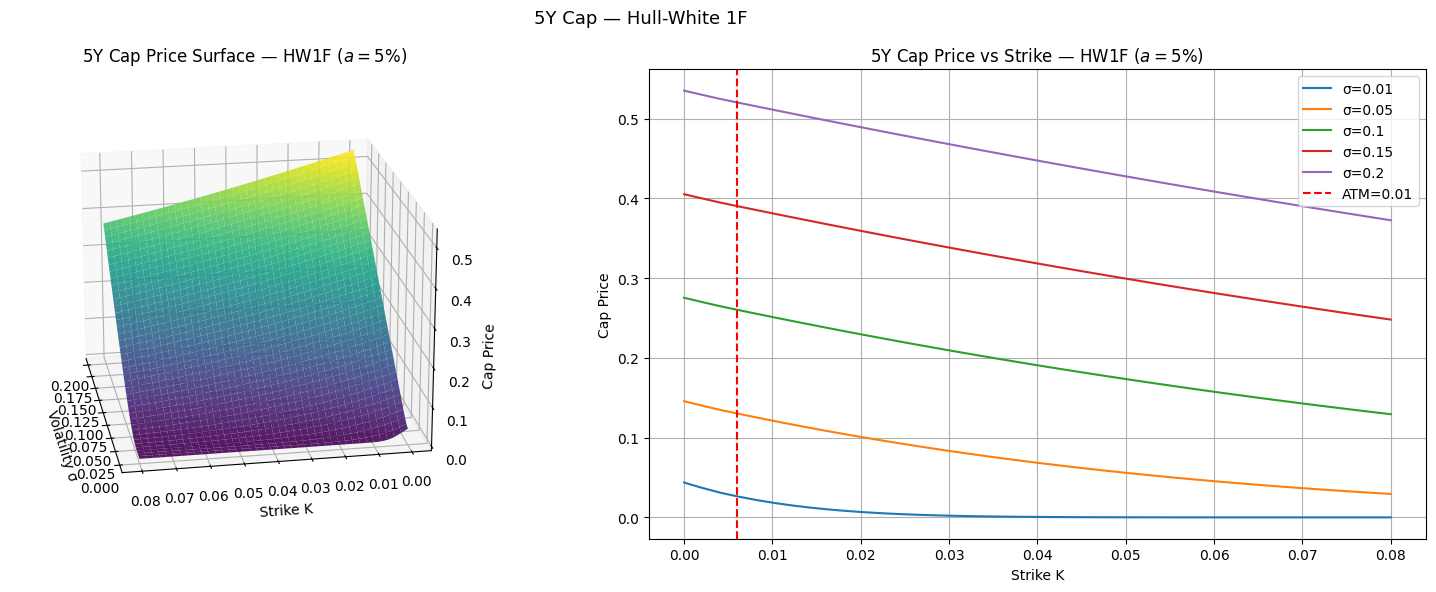

In [90]:
model.a = 0.05
K_atm = model.swap_rate(0, 0, 60)

sigma_range_surface = np.linspace(0.001, 0.20, 40)
K_range             = np.linspace(0.00, 0.08, 40)
sigma_levels        = [0.01, 0.05, 0.10, 0.15, 0.20]

Sigma, K_grid = np.meshgrid(sigma_range_surface, K_range)
Price_surface = np.zeros_like(Sigma)

for i in range(Sigma.shape[0]):
    for j in range(Sigma.shape[1]):
        model.sigma   = Sigma[i, j]
        Price_surface[i, j] = model.cap_Jamshidian(0, 0, 60, K_grid[i, j])

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(Sigma , K_grid , Price_surface, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Volatility σ')
ax1.set_ylabel('Strike K')
ax1.set_zlabel('Cap Price')
ax1.set_title(r'5Y Cap Price Surface — HW1F ($a=5\%$)')
ax1.view_init(elev=20, azim=170)

ax2 = fig.add_subplot(122)
for s in sigma_levels:
    model.sigma = s
    prices = [model.cap_Jamshidian(0, 0, 60, k) for k in K_range]
    ax2.plot(K_range , prices, label=f'σ={s}')

ax2.axvline(K_atm , color='red', linestyle='--', lw=1.5, label=f'ATM={K_atm:.2f}')
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Cap Price')
ax2.set_title(r'5Y Cap Price vs Strike — HW1F ($a=5\%$)')
ax2.legend()
ax2.grid(True)

plt.suptitle(r'5Y Cap — Hull-White 1F', fontsize=13)
plt.tight_layout()
plt.show()

## Calibration to ATM Cap Prices

Following the same approach as for swaptions, we fix $a = 6\%$ and calibrate 
$\sigma$ by minimizing the sum of squared price differences between the HW1F 
model and market ATM cap prices for maturities 1Y and 2Y with quarterly payments:

$$\min_{\sigma > 0} \sum_{T \in \{1Y,\, 2Y\}} \left(V^{mkt}_T - V^{model}_T(\sigma)\right)^2$$

Market prices are computed from the caplet vol surface via Black's formula, 
summing individual caplet prices. The implied vol of each cap is then obtained 
by inverting a flat-vol Black formula — the standard market convention.

The calibration yields $\sigma = 0.335\%$, compared to $\sigma = 0.464\%$ from 
the swaption calibration. This discrepancy is not a numerical artifact — it 
reflects the fact that **HW1F with constant parameters cannot simultaneously 
fit caps and swaptions**. The model overprices the 1Y cap and slightly underprices 
the 2Y, reproducing the same pattern observed in the swaption calibration: a 
single $\sigma$ cannot capture the vol term structure across maturities. In 
practice, a time-dependent $\sigma(t)$ or a richer model such as LMM would be 
required to achieve a consistent fit across both markets.

In [97]:
from scipy.optimize import brentq

# ── Calibration ───────────────────────────────────────────────────────────────
cap_surface    = pd.read_excel("Market Data/cap vol surface.xlsx", index_col=0, header=0)
cap_maturities = [12, 24]

def objective_cap(params):
    a, sigma = params
    model.a     = a
    model.sigma = sigma
    error = 0
    for maturity in cap_maturities:
        strike       = model.swap_rate(0, 0, maturity)
        market_price = model.cap_black(0, maturity, strike, cap_surface)
        model_price  = model.cap_Jamshidian(0, 0, maturity, strike)
        error += (market_price - model_price) ** 2
    return error

result_cap = minimize(objective_cap,
                      x0=[0.05, 0.01],
                      bounds=[(1e-4, 1.0), (1e-4, 1.0)])

a_cal_cap, sigma_cal_cap = result_cap.x
model.a     = a_cal_cap
model.sigma = sigma_cal_cap

print(f"Calibrated a     = {a_cal_cap:.5f}")
print(f"Calibrated sigma = {sigma_cal_cap:.5f}")

# ── Calibration report ────────────────────────────────────────────────────────
data = {}
for maturity in cap_maturities:
    strike       = model.swap_rate(0, 0, maturity)
    market_price = model.cap_black(0, maturity, strike, cap_surface)
    model_price  = model.cap_Jamshidian(0, 0, maturity, strike)
    market_vol   = brentq(lambda v: model.cap_black_flat(0, maturity, strike, v) - market_price, 1e-6, 2.0)
    model_vol    = brentq(lambda v: model.cap_black_flat(0, maturity, strike, v) - model_price,  1e-6, 2.0)

    data.setdefault("Market Price", []).append(round(market_price, 6))
    data.setdefault("Model Price",  []).append(round(model_price,  6))
    data.setdefault("Market Vol",   []).append(round(market_vol,   4))
    data.setdefault("Model Vol",    []).append(round(model_vol,    4))
    data.setdefault("Error Price",  []).append(round(model_price - market_price, 6))
    data.setdefault("Error Vol",    []).append(round(model_vol - market_vol,     4))

index = [f"0Y x {maturity//12}Y" for maturity in cap_maturities]
df_cap_cal = pd.DataFrame(data, index=index)
print(df_cap_cal.to_string())
print(f"\nCumulated error price : {df_cap_cal['Error Price'].abs().sum():.6f}")
print(f"Cumulated error vol   : {df_cap_cal['Error Vol'].abs().sum():.4f}")

Calibrated a     = 0.05004
Calibrated sigma = 0.00333
         Market Price  Model Price  Market Vol  Model Vol  Error Price  Error Vol
0Y x 1Y      0.000548     0.000701      0.6266     0.8156     0.000152     0.1890
0Y x 2Y      0.002292     0.002249      0.7483     0.7326    -0.000043    -0.0157

Cumulated error price : 0.000195
Cumulated error vol   : 0.2047


## Calibration with Fixed Mean-Reversion Speed

Following the same approach as in the swaption calibration, we fix the 
mean-reversion speed $a$ exogenously and calibrate only $\sigma$:

$$\min_{\sigma > 0} \sum_{T \in \{1Y,\, 2Y\}} \left(V^{mkt}_T - V^{model}_T(\sigma)\right)^2$$

As discussed earlier, $a$ is typically fixed between 3% and 10% in practice, 
either from historical estimation or market convention. We fix $a = 6\%$ and 
find that the one-dimensional calibration yields a better fit than the joint 
$(a, \sigma)$ calibration — a direct consequence of the identification problem 
illustrated by the price surface above, where many $(a, \sigma)$ pairs produce 
nearly identical prices.

In [98]:
from scipy.optimize import brentq

# ── Calibration ───────────────────────────────────────────────────────────────
cap_surface    = pd.read_excel("Market Data/cap vol surface.xlsx", index_col=0, header=0)
cap_maturities = [12, 24]
model.a = 0.06 #a = 5% fixed
def objective_cap(params):
    sigma = params
    model.sigma = sigma
    error = 0
    for maturity in cap_maturities:
        strike       = model.swap_rate(0, 0, maturity)
        market_price = model.cap_black(0, maturity, strike, cap_surface)
        model_price  = model.cap_Jamshidian(0, 0, maturity, strike)
        error += (market_price - model_price) ** 2
    return error

result_cap = minimize(objective_cap,
                      x0=[0.01],
                      bounds=[(1e-4, 1.0)])

sigma_cal_cap = result_cap.x[0]
model.sigma = sigma_cal_cap

print(f"Fixed a     = {model.a:.5f}")
print(f"Calibrated sigma = {sigma_cal_cap:.5f}")

# ── Calibration report ────────────────────────────────────────────────────────
data = {}
for maturity in cap_maturities:
    strike       = model.swap_rate(0, 0, maturity)
    market_price = model.cap_black(0, maturity, strike, cap_surface)
    model_price  = model.cap_Jamshidian(0, 0, maturity, strike)
    market_vol   = brentq(lambda v: model.cap_black_flat(0, maturity, strike, v) - market_price, 1e-6, 2.0)
    model_vol    = brentq(lambda v: model.cap_black_flat(0, maturity, strike, v) - model_price,  1e-6, 2.0)

    data.setdefault("Market Price", []).append(round(market_price, 6))
    data.setdefault("Model Price",  []).append(round(model_price,  6))
    data.setdefault("Market Vol",   []).append(round(market_vol,   4))
    data.setdefault("Model Vol",    []).append(round(model_vol,    4))
    data.setdefault("Error Price",  []).append(round(model_price - market_price, 6))
    data.setdefault("Error Vol",    []).append(round(model_vol - market_vol,     4))

index = [f"0Y x {maturity//12}Y" for maturity in cap_maturities]
df_cap_cal = pd.DataFrame(data, index=index)
print(df_cap_cal.to_string())
print(f"\nCumulated error price : {df_cap_cal['Error Price'].abs().sum():.6f}")
print(f"Cumulated error vol   : {df_cap_cal['Error Vol'].abs().sum():.4f}")

Fixed a     = 0.06000
Calibrated sigma = 0.00335
         Market Price  Model Price  Market Vol  Model Vol  Error Price  Error Vol
0Y x 1Y      0.000548     0.000703      0.6266     0.8179     0.000154     0.1913
0Y x 2Y      0.002292     0.002249      0.7483     0.7325    -0.000044    -0.0158

Cumulated error price : 0.000198
Cumulated error vol   : 0.2071


## Cap Calibration Error Surface

As for swaptions, the error surface exhibits a clear valley structure — 
a continuous ridge of $(a, \sigma)$ pairs achieving near-zero error, making 
joint calibration unstable. Fixing $a$ exogenously reduces the problem to a 
one-dimensional convex optimization with a unique minimum.

The key finding is not in the shape of the surface but in the calibrated values: 
caps and swaptions yield **different $(a, \sigma)$ pairs**, meaning HW1F with 
constant parameters cannot simultaneously fit both markets — a fundamental 
limitation that motivates richer models such as HW2F or LMM.

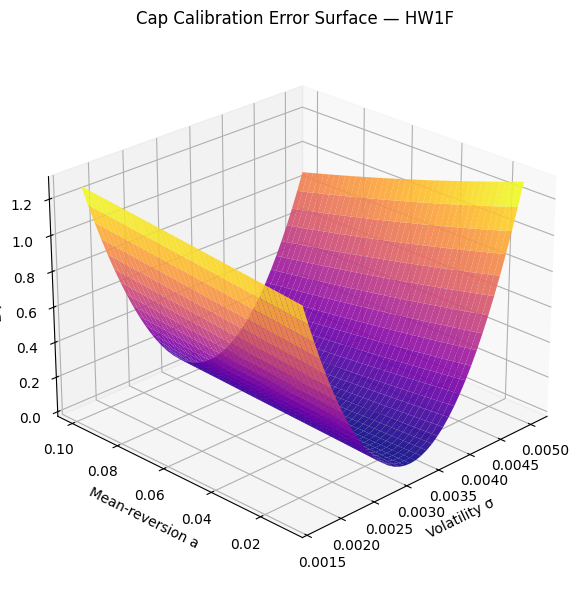

In [94]:
sigma_range  = np.linspace(sigma_cal_cap-sigma_cal_cap/2, sigma_cal_cap+sigma_cal_cap/2, 40)
a_range      = np.linspace(0.01, 0.1, 40)
sigma, a     = np.meshgrid(sigma_range, a_range)
Errors       = np.zeros_like(sigma)
market_price = model.cap_black(0, cap_maturities[1], model.swap_rate(0, 0, cap_maturities[1]), cap_surface)

for i in range(sigma.shape[0]):
    for j in range(sigma.shape[1]):
        model.a     = a[i][j]
        model.sigma = sigma[i][j]
        p           = model.cap_Jamshidian(0, 0, cap_maturities[1], model.swap_rate(0, 0, cap_maturities[1]))
        Errors[i][j] = (p - market_price) ** 2

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(sigma, a, Errors, cmap='plasma', edgecolor='none', alpha=0.9)
ax.set_xlabel('Volatility σ')
ax.set_ylabel('Mean-reversion a')
ax.set_zlabel('Squared Error')
ax.set_title(r'Cap Calibration Error Surface — HW1F')
ax.view_init(elev=25, azim=-135)
plt.tight_layout()
plt.show()